In [1]:
import pandas as pd
import numpy as np


In [2]:
import matplotlib.pyplot as plt

In [3]:
df_train = pd.read_csv('train.csv')
df_train.head(5)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
x = df_train.drop(['SalePrice'],axis=1)
y = df_train['SalePrice']

In [6]:
x

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal


In [7]:
y

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

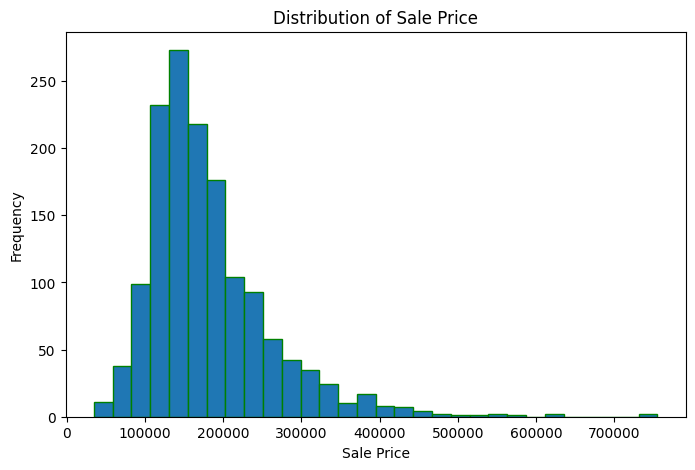

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import base
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(y, bins=30, edgecolor='green')
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.show()

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

X = df_train.drop(columns=['SalePrice'])
Y = df_train['SalePrice']

X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded = X_encoded.fillna(0)

def train_model(X_data, Y_data):
    X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, Y_train)
    
    predictions = model.predict(X_test)
    mae = mean_absolute_error(Y_test, predictions)
    r2 = r2_score(Y_test, predictions)
    
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"R2 Score: {r2:.4f}")
    return model

trained_model = train_model(X_encoded, Y)

Mean Absolute Error: 20513.17
R2 Score: 0.6817


In [10]:
from sklearn.preprocessing import LabelEncoder
encoded_df = pd.DataFrame()

label = LabelEncoder()
for c in df_train.columns:
    if df_train[c].dtype == 'object':
         encoded_df[c] = label.fit_transform(df_train[c].astype(str))
    else:
        encoded_df[c] = df_train[c]
encoded_df.head(5)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,3,65.0,8450,1,2,3,3,0,...,0,3,4,4,0,2,2008,8,4,208500
1,2,20,3,80.0,9600,1,2,3,3,0,...,0,3,4,4,0,5,2007,8,4,181500
2,3,60,3,68.0,11250,1,2,0,3,0,...,0,3,4,4,0,9,2008,8,4,223500
3,4,70,3,60.0,9550,1,2,0,3,0,...,0,3,4,4,0,2,2006,8,0,140000
4,5,60,3,84.0,14260,1,2,0,3,0,...,0,3,4,4,0,12,2008,8,4,250000


In [11]:
import pandas as pd

In [12]:
full_corr_matrix = encoded_df.corr()
price_correlations = full_corr_matrix['SalePrice'].sort_values(ascending=False)

print(price_correlations.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


In [14]:
import seaborn as sns

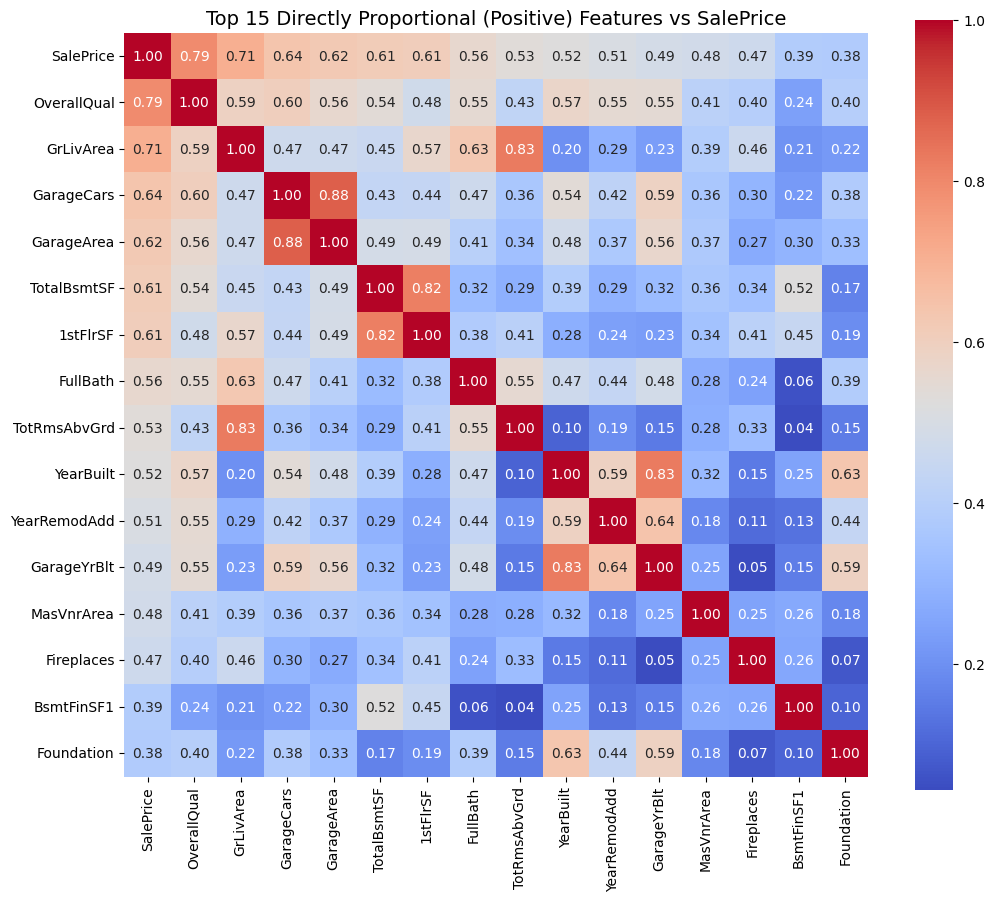

Accuracy Score using 15 POSITIVE features: 79.21%


In [15]:
top_15_pos = price_correlations.index[1:16].tolist()
pos_matrix_30 = encoded_df[['SalePrice'] + top_15_pos].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(pos_matrix_30, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Top 15 Directly Proportional (Positive) Features vs SalePrice', fontsize=14)
plt.show()


X_pos_15 = encoded_df[top_15_pos].fillna(0) 
y = encoded_df['SalePrice']

model_pos_15 = LinearRegression()
model_pos_15.fit(X_pos_15, y)
predictions_pos_15 = model_pos_15.predict(X_pos_15)


accuracy_pos_15 = r2_score(y, predictions_pos_15)
print(f"Accuracy Score using 15 POSITIVE features: {accuracy_pos_15:.2%}")

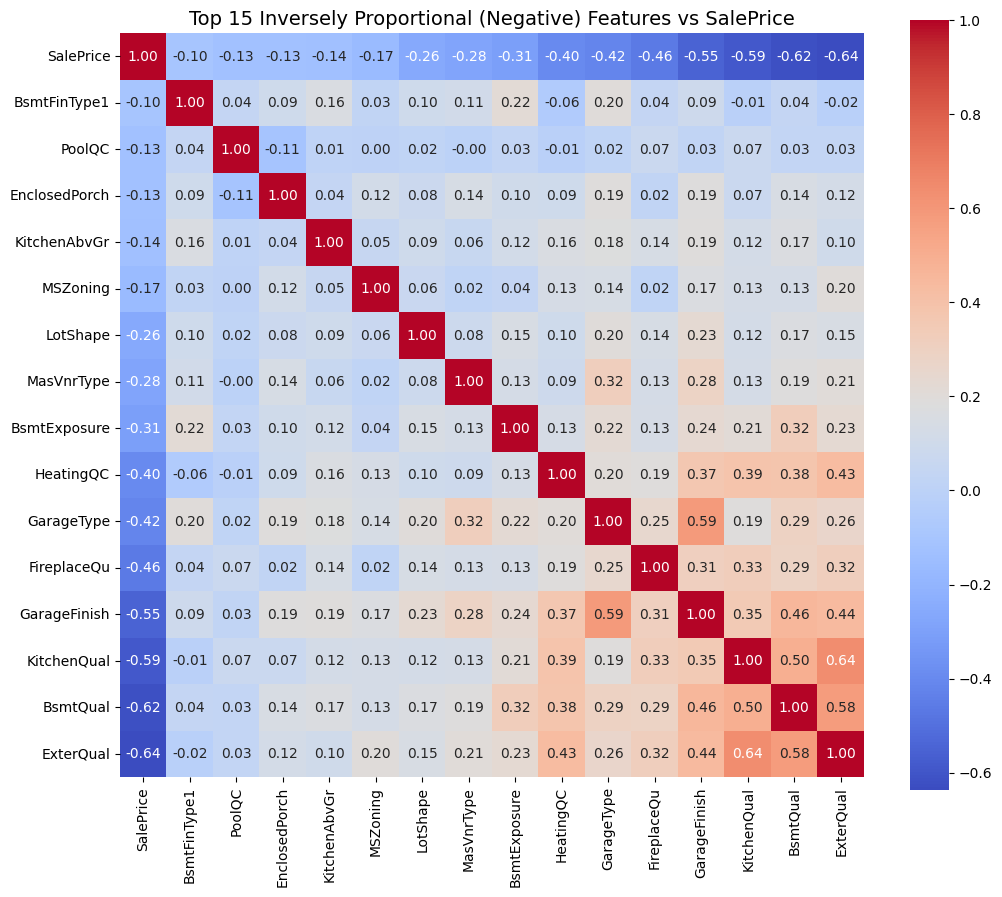

Accuracy Score using 15 INVERSE features: 64.22%


In [16]:
top_15_neg = price_correlations.tail(15).index.tolist()

neg_matrix_30 = encoded_df[['SalePrice'] + top_15_neg].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(neg_matrix_30, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Top 15 Inversely Proportional (Negative) Features vs SalePrice', fontsize=14)
plt.show()

X_neg_15 = encoded_df[top_15_neg].fillna(0)  
y = encoded_df['SalePrice']

model_neg_15 = LinearRegression()
model_neg_15.fit(X_neg_15, y)
predictions_neg_15 = model_neg_15.predict(X_neg_15)

accuracy_neg_15 = r2_score(y, predictions_neg_15)
print(f"Accuracy Score using 15 INVERSE features: {accuracy_neg_15:.2%}")

In [17]:
onehot_df = pd.get_dummies(df_train)

onehot_clean = onehot_df.fillna(0)

print(f"Original shape: {df_train.shape}")
print(f"New One-Hot shape: {onehot_clean.shape}")

Original shape: (1460, 81)
New One-Hot shape: (1460, 289)


In [18]:
X_all = onehot_clean.drop(columns=['SalePrice'])
y_all = onehot_clean['SalePrice']

model_all = LinearRegression()
model_all.fit(X_all, y_all)

predictions_all = model_all.predict(X_all)
total_accuracy = r2_score(y_all, predictions_all)

print(f"Total One-Hot Encoded Model Accuracy: {total_accuracy:.2%}")

Total One-Hot Encoded Model Accuracy: 93.32%


In [19]:
import numpy as np
df_train['MoSold_sin'] = np.sin(2 * np.pi * df_train['MoSold'] / 12)
df_train['MoSold_cos'] = np.cos(2 * np.pi * df_train['MoSold'] / 12)
df_cyclic = df_train.drop(columns=['MoSold'])
onehot_cyclic_df = pd.get_dummies(df_cyclic)

onehot_cyclic_clean = onehot_cyclic_df.fillna(0)

X_cyclic = onehot_cyclic_clean.drop(columns=['SalePrice'])
y_cyclic = onehot_cyclic_clean['SalePrice']


model_cyclic = LinearRegression()
model_cyclic.fit(X_cyclic, y_cyclic)


predictions_cyclic = model_cyclic.predict(X_cyclic)
accuracy_cyclic = r2_score(y_cyclic, predictions_cyclic)

print(f"Combined Cyclic + One-Hot Accuracy: {accuracy_cyclic:.2%}")

Combined Cyclic + One-Hot Accuracy: 93.34%


In [21]:
from sklearn.feature_extraction import FeatureHasher


In [22]:
hasher = FeatureHasher(n_features=5, input_type='string')

neighborhood_dict = df_train[['Neighborhood']].astype(str).to_dict(orient='records')
hashed_features = hasher.transform([list(d.values()) for d in neighborhood_dict])

hashed_df = pd.DataFrame(hashed_features.toarray(), columns=[f'Neigh_Hash_{i}' for i in range(5)])

core_numeric = df_train[['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF']].fillna(0)

X_hashed = pd.concat([core_numeric, hashed_df], axis=1)
y = df_train['SalePrice']

model_hash = LinearRegression()
model_hash.fit(X_hashed, y)
predictions_hash = model_hash.predict(X_hashed)

accuracy_hash = r2_score(y, predictions_hash)
print(f" Feature Hashing (Neighborhood Only) + 4 Core Features Accuracy: {accuracy_hash:.2%}")

 Feature Hashing (Neighborhood Only) + 4 Core Features Accuracy: 77.48%


In [23]:
from sklearn.feature_extraction import FeatureHasher

text_data = df_train[['Neighborhood', 'ExterQual']].astype(str)

text_records = text_data.values.tolist()

hasher = FeatureHasher(n_features=5, input_type='string')
hashed_features = hasher.transform(text_records)



hashed_df = pd.DataFrame(hashed_features.toarray(), columns=[f'Text_Hash_{i}' for i in range(5)])

numeric_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt', 'FullBath']
core_numeric = df_train[numeric_features].fillna(0)

X_combined = pd.concat([core_numeric, hashed_df], axis=1)
y = df_train['SalePrice']

model_combined = LinearRegression()
model_combined.fit(X_combined, y)
predictions_combined = model_combined.predict(X_combined)

accuracy_combined = r2_score(y, predictions_combined)
print(f" Hashing Model Accuracy (7 Features Total): {accuracy_combined:.2%}")

 Hashing Model Accuracy (7 Features Total): 78.13%


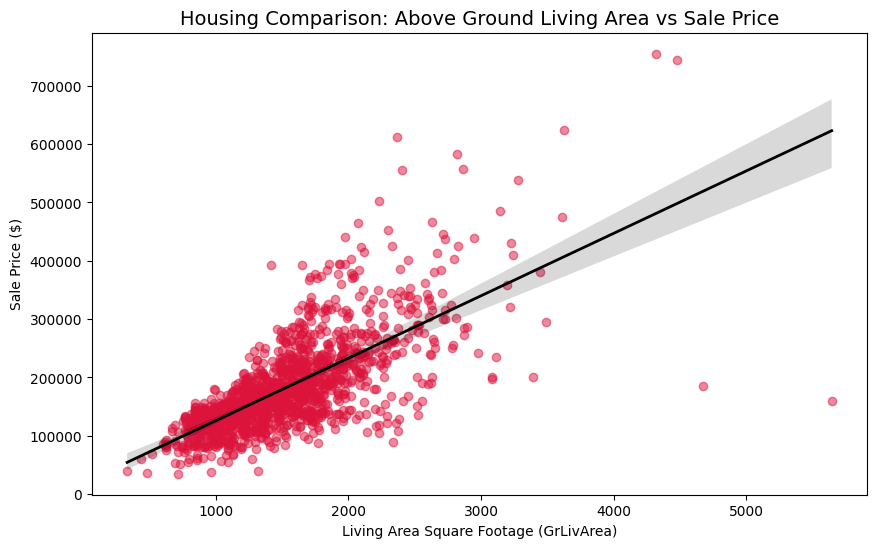

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_train, 
    x='GrLivArea', 
    y='SalePrice',
    scatter_kws={'alpha': 0.5, 'color': 'crimson'},
    line_kws={'color': 'black', 'linewidth': 2}
)

plt.title('Housing Comparison: Above Ground Living Area vs Sale Price', fontsize=14)
plt.xlabel('Living Area Square Footage (GrLivArea)')
plt.ylabel('Sale Price ($)')

plt.show()


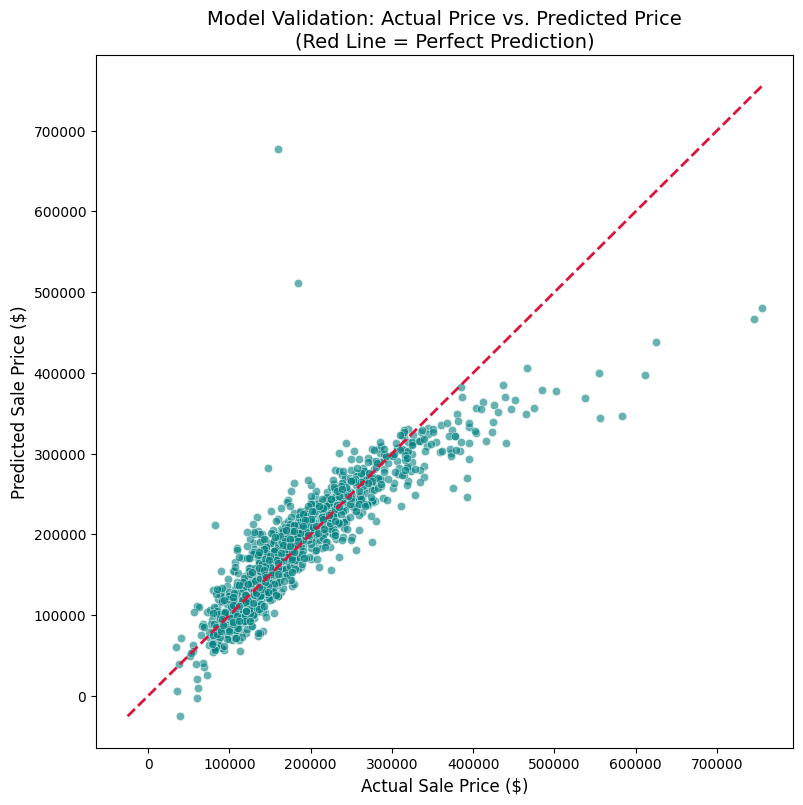

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

X_pos_15 = encoded_df[top_15_pos].fillna(0)
actual_prices = encoded_df['SalePrice']
predicted_prices = model_pos_15.predict(X_pos_15)

plt.figure(figsize=(9, 9))

sns.scatterplot(x=actual_prices, y=predicted_prices, alpha=0.6, color='teal')

min_val = min(actual_prices.min(), predicted_prices.min())
max_val = max(actual_prices.max(), predicted_prices.max())
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', linewidth=2)

plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.title('Model Validation: Actual Price vs. Predicted Price\n(Red Line = Perfect Prediction)', fontsize=14)

plt.ticklabel_format(style='plain', axis='both')

plt.show()


In [27]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_pos_15 = mean_absolute_error(actual_prices, predicted_prices)
r2_pos_15 = r2_score(actual_prices, predicted_prices)

print(f"15-Feature Model Performance:")
print(f"Mean Absolute Error: {mae_pos_15:.2f}")
print(f"R2 Score: {r2_pos_15:.4f}")


15-Feature Model Performance:
Mean Absolute Error: 22533.38
R2 Score: 0.7921


In [30]:
from sklearn.model_selection import cross_val_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(LinearRegression(), X_pos_15, actual_prices, cv=kf, scoring='r2')

print(f"Cross-Validation R2 Scores: {cv_scores}")
print(f"Mean R2 Score: {np.mean(cv_scores):.4f}")
print(f"R2 Score Standard Deviation: {np.std(cv_scores):.4f}")


Cross-Validation R2 Scores: [0.81283691 0.82844287 0.43014796 0.81447993 0.85041204]
Mean R2 Score: 0.7473
R2 Score Standard Deviation: 0.1591
